### Forcing Extremes
##### Goal: Visually observe underfitting and overfitting.
##### Task: Generate a non-linear regression dataset using make_regression or mathematical functions (like a noisy sine wave).
##### Deliverable: Train three DecisionTreeRegressor models: one with max_depth=1 (high bias), one with max_depth=3 (balanced), and one with max_depth=None (high variance). Plot the true data alongside the prediction lines of all three models on the same graph using Matplotlib or Seaborn.

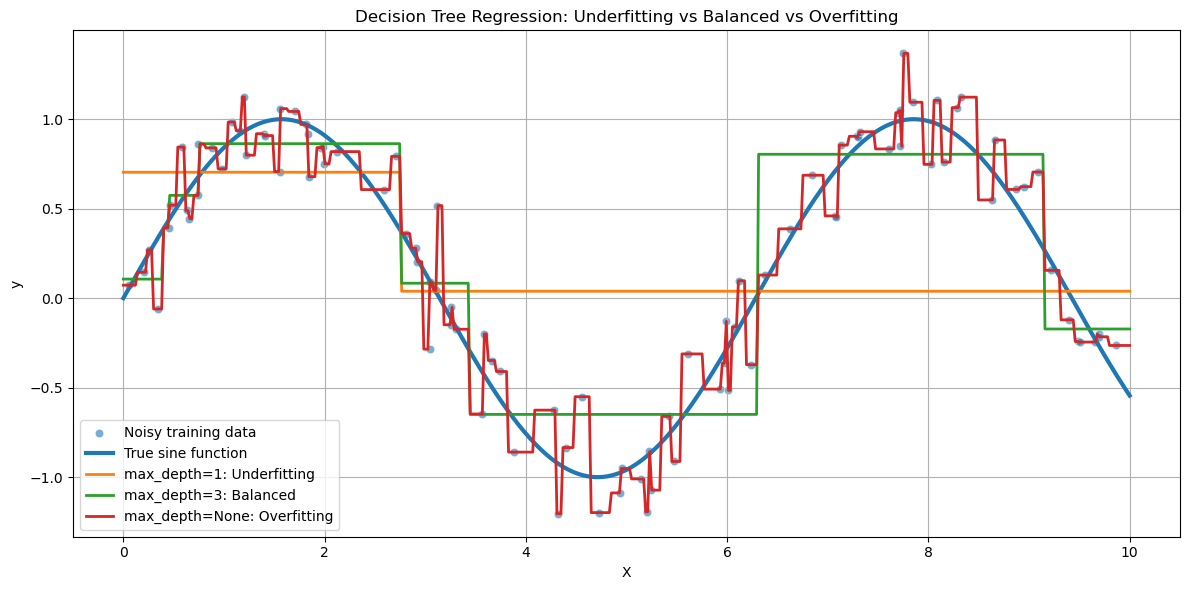

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor

np.random.seed(42)

X = np.sort(np.random.rand(100, 1) * 10, axis=0)
y_true = np.sin(X).ravel()
y = y_true + np.random.normal(0, 0.2, X.shape[0])

tree_depth_1 = DecisionTreeRegressor(max_depth=1, random_state=42)
tree_depth_3 = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_full    = DecisionTreeRegressor(max_depth=None, random_state=42)

tree_depth_1.fit(X, y)
tree_depth_3.fit(X, y)
tree_full.fit(X, y)

X_test = np.linspace(0, 10, 500).reshape(-1, 1)

y_pred_depth_1 = tree_depth_1.predict(X_test)
y_pred_depth_3 = tree_depth_3.predict(X_test)
y_pred_full    = tree_full.predict(X_test)

plt.figure(figsize=(12, 6))

sns.scatterplot(x=X.ravel(), y=y, label="Noisy training data", alpha=0.6)
plt.plot(X_test, np.sin(X_test), label="True sine function",       linewidth=3)
plt.plot(X_test, y_pred_depth_1, label="max_depth=1: Underfitting", linewidth=2)
plt.plot(X_test, y_pred_depth_3, label="max_depth=3: Balanced",     linewidth=2)
plt.plot(X_test, y_pred_full,    label="max_depth=None: Overfitting",linewidth=2)

plt.title("Decision Tree Regression: Underfitting vs Balanced vs Overfitting")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()